# Relevant Links
By: Magnus Vaslag Løvøy
Github: https://github.com/magloev/magloevIND320
Streamlit app: https://magloevind320.streamlit.app/

In [32]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv('../data/reservoirs.csv')

#Renaming the columns to reasonable English equivalents
df = df.rename(columns= {
    "dato_Id" : "date",
    "omrType" : "area_type",
    "omrnr"   : "area_id",
    "iso_aar" : "iso_year",
    "iso_uke"  : "iso_week",
    "fyllingsgrad" : "fill_level",
    "kapasitet_TWh" : "capacity_TWh",
    "fylling_TWh" : "stored_energy_TWh",
    "neste_Publiseringsdato" : "next_publication_date", 
    "fyllingsgrad_forrige_uke" : "fill_level_prev_week",
    "endring_fyllingsgrad" : "fill_level_change" })

#Sort the data by date
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(by="date")

df.tail(20)

,date,area_type,area_id,iso_year,iso_week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_prev_week,fill_level_change
8252,2026-08-23,EL,5,2026,34,0.641755,17.390587,11.160489,2026-09-02T13:00:00,0.653499,-0.011744
14849,2026-08-23,VASS,1,2026,34,0.570732,36.044464,20.571724,2026-09-02T13:00:00,0.583680,-0.012948
14874,2026-08-30,VASS,3,2026,35,0.827718,28.155403,23.304743,2026-09-09T13:00:00,0.829898,-0.002180
8235,2026-08-30,EL,2,2026,35,0.459006,34.043590,15.626217,2026-09-09T13:00:00,0.466285,-0.007279
9916,2026-08-30,NO,0,2026,35,0.634381,87.437580,55.468720,2026-09-09T13:00:00,0.639524,-0.005144
8257,2026-08-30,EL,5,2026,35,0.635164,17.390587,11.045877,2026-09-09T13:00:00,0.641756,-0.006592
8255,2026-08-30,EL,4,2026,35,0.906874,21.079208,19.116190,2026-09-09T13:00:00,0.907567,-0.000693
8259,2026-08-30,EL,3,2026,35,0.627002,8.920932,5.593442,2026-09-09T13:00:00,0.637280,-0.010278
14858,2026-08-30,VASS,2,2026,35,0.514370,23.237715,11.952795,2026-09-09T13:00:00,0.525298,-0.010928
14856,2026-08-30,VASS,1,2026,35,0.567064,36.044464,20.439535,2026-09-09T13:00:00,0.570706,-0.003641


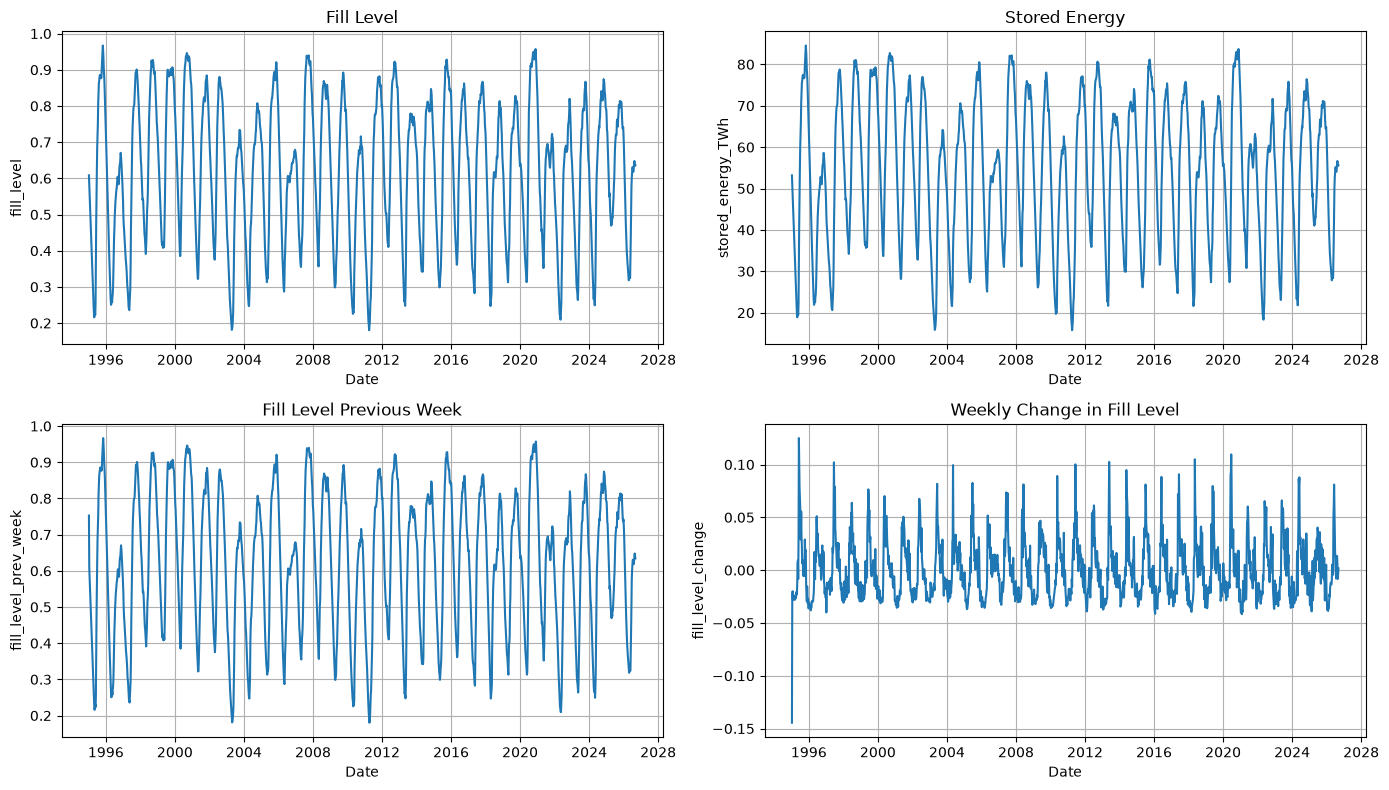

,date,area_type,area_id,iso_year,iso_week,fill_level,capacity_TWh,stored_energy_TWh,next_publication_date,fill_level_prev_week,fill_level_change
3468,1995-01-08,EL,5,1995,1,0.616448,17.390587,10.720388,0001-01-01T00:00:00,0.614288,0.002160
3361,1995-01-08,EL,4,1995,1,0.558864,21.079208,11.780413,0001-01-01T00:00:00,0.801348,-0.242484
5036,1995-01-08,EL,3,1995,1,0.602376,8.920932,5.373754,0001-01-01T00:00:00,0.596027,0.006349
3113,1995-01-08,EL,1,1995,1,0.621467,6.003264,3.730831,0001-01-01T00:00:00,0.734888,-0.113421
7739,1995-01-08,EL,2,1995,1,0.630947,34.043590,21.479713,0001-01-01T00:00:00,0.777604,-0.146657
11380,1995-01-08,VASS,2,1995,1,0.608856,23.237715,14.148431,0001-01-01T00:00:00,0.744693,-0.135837
14162,1995-01-08,VASS,1,1995,1,0.636038,36.044464,22.925638,0001-01-01T00:00:00,0.798825,-0.162787
11198,1995-01-08,VASS,3,1995,1,0.566906,28.155403,15.961480,0001-01-01T00:00:00,0.661432,-0.094525
8501,1995-01-08,NO,0,1995,1,0.608274,87.437580,53.185986,0001-01-01T00:00:00,0.752703,-0.144430
13262,1995-01-15,VASS,2,1995,2,0.588298,23.237715,13.670702,0001-01-01T00:00:00,0.608854,-0.020556


In [ ]:
#Select the national data
df_no = df[(df["area_type"] == "NO")].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

columns = [
    "fill_level",
    "stored_energy_TWh",
    "fill_level_prev_week",
    "fill_level_change"
]

titles = [
    "Fill Level",
    "Stored Energy",
    "Fill Level Previous Week",
    "Weekly Change in Fill Level"
]
#Plotting for all the different columns in one plot
for ax, column, title in zip(axes.flatten(), columns, titles):
    ax.plot(df_no["date"], df_no[column])
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(column)
    ax.grid()

plt.tight_layout()
plt.show()


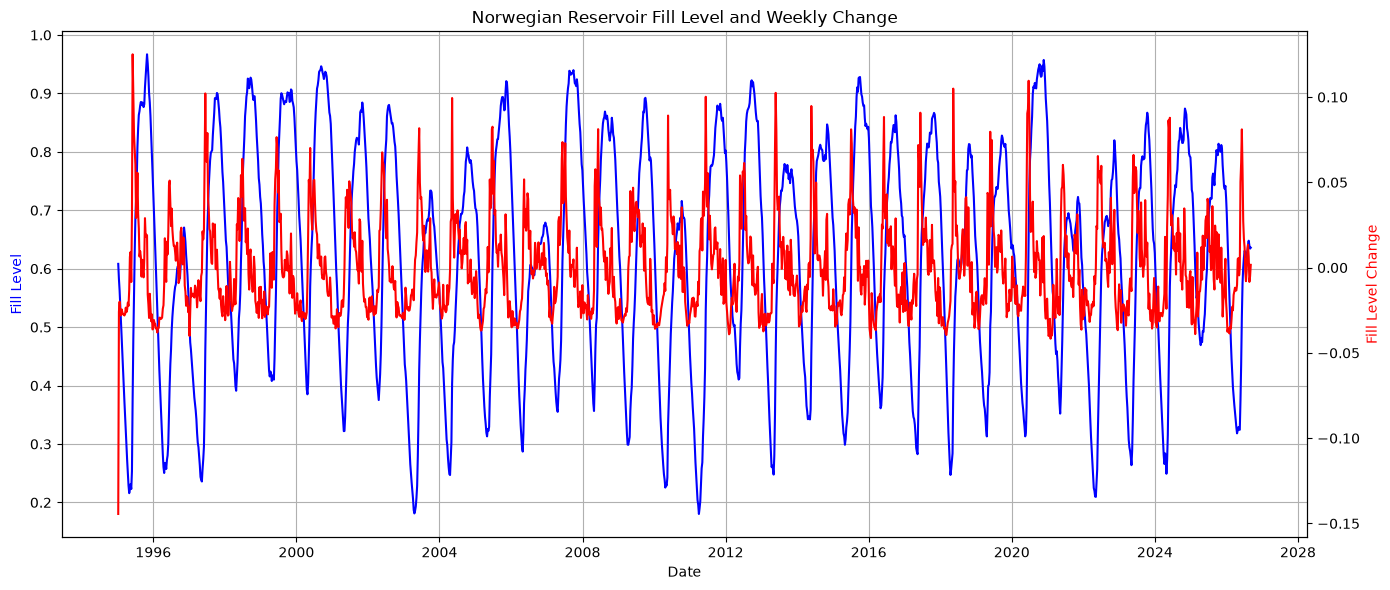

In [ ]:
fig, ax1 = plt.subplots(figsize=(14, 6))

#display fill level on the left y-axis
ax1.plot(
    df_no["date"],
    df_no["fill_level"],
    label="Fill Level",
    color="blue"
)

ax1.set_xlabel("Date")
ax1.set_ylabel("Fill Level", color="blue")
ax1.grid()

#display change in fill level on right y-axis
ax2 = ax1.twinx()

ax2.plot(
    df_no["date"],
    df_no["fill_level_change"],
    label="Fill Level Change",
    color="red"
)

ax2.set_ylabel("Fill Level Change", color="red")

plt.title("Norwegian Reservoir Fill Level and Weekly Change")

fig.tight_layout()
plt.show()

# AI Usage

# Log
Started with exploring the dataset. Firstly renamed the columns to feasible english names and also sorted the dataset by date. Found fill_level, stored_energy_TWh, fill_level_prev_week and fill_level_change to be relevant data to show on plots. Decided to use the area_type == "NO" for now, to show the national data, just to make it simpler for display purposes for now. When looking at the fill_level_change i saw that the first recorded values were unusually small number (-0.14) whereas all the others are around a minimum of (-0.05). I checked the calculations myself but it all checked out according to the data so decided to still keep it in. Firstly plotted all of the variables separately. When working with displaying them all together by normalizing, since stored_energy_TWh = fill_level x capacity_TWh, with capacity_TWh being a constant, and that fill_level_prev week is fill_level just shifted one week backwards, i decided that it was reasonable to only plot fill_level and fill_level_change against date. Since fill_level_change contains negative values and fill_level is percentage from 0-1, i used two different y-axis, as normalizing the negative values would destroy its meaning. This provides a much cleaner and visible plot without removing anything important, so i also used this for the "All columns" plot in the streamlit app. Moving on to the streamlit app itself, with emphasis on the "plots" page which contains the most code. Firstly i added a separate "data_loader.py" file under "src" folder. Considering reservoirdata and plots uses the same loading and cleaning of the csv file it would be cleaner to have it as its own program which is imported by the py-files using it. It also contains the caching of the data here. In the plots.py I used the selectbox, select_slider etc with some if tests to make sure the correct selection shows the correct plot. I found it pretty effective and intuitive to work with streamlit in the python code and made it pretty simple to set up the webpage cleanly in my opinion. 
